TEST 2: Finite Alphabet Limit on Bell's Inequality (CHSH)

[TEST 2] Exploring CHSH violation for different alphabet sizes...

  Results for d_max = 9 (Our Finitist Model):
    Maximum |S| = 1.6004
    Angles used: ['0.0°', '20.0°', '40.0°', '60.0°']
    (Optimal angles require 22.5° precision)

  ✓ Saved: test2_bell_alphabet_limit.png


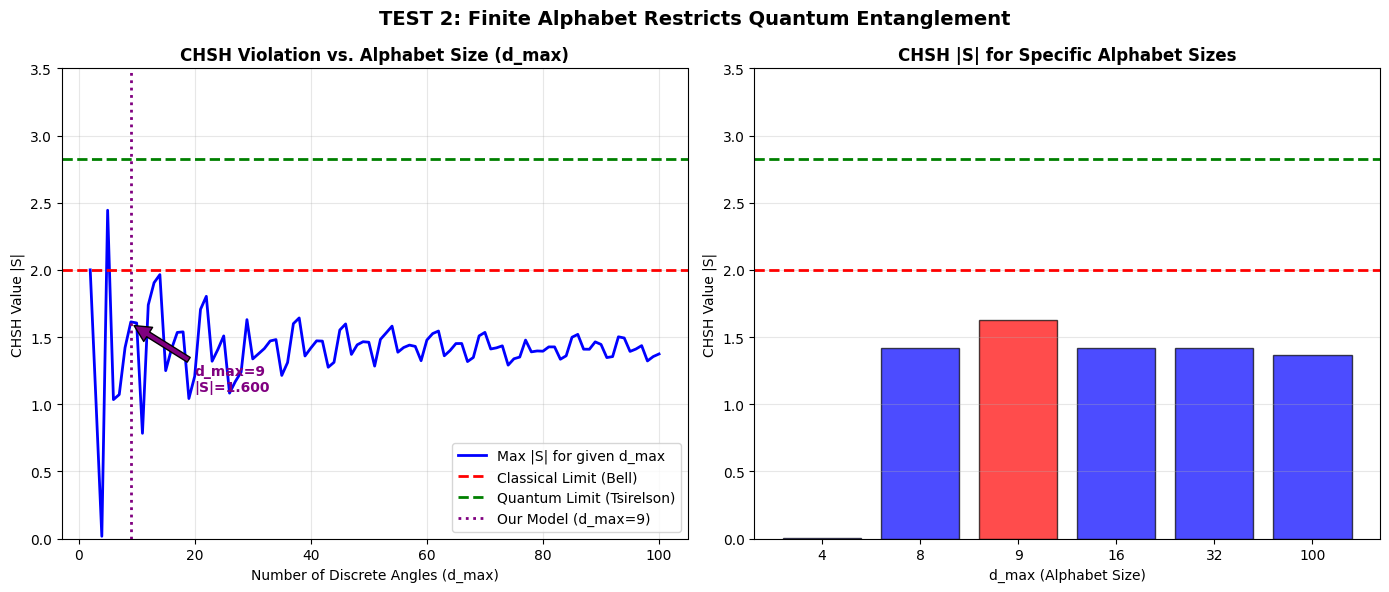


INTERPRETATION
• As d_max increases, the maximum possible |S| approaches 2.828.
• For small d_max (like our d_max=9), the hardware cannot resolve
  the fine angles (22.5°) needed for maximum violation.
• PREDICTION: If the universe has a finite alphabet (d_max=9),
  ultra-precise Bell tests should show |S| < 2.828.
• The 'missing' violation is not a failure of quantum mechanics,
  but a hardware limitation of the discrete causal graph.


In [3]:
"""
finitist_bell_alphabet_limit.py
================================
TEST 2 (FINAL): The Effect of Finite Alphabet (d_max) on CHSH Violation.
Simulates quantum correlations but restricts measurement angles to d_max discrete steps.

Author: Néstor E. Ramos
For: "The Topology of the Pixelated Universe"
"""

import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("TEST 2: Finite Alphabet Limit on Bell's Inequality (CHSH)")
print("=" * 70)

# =============================================================================
# SIMULATION ENGINE
# =============================================================================

def simulate_CHSH_for_dmax(d_max, N_trials=50000):
    """
    Simulates CHSH test for a given alphabet size (number of discrete angles).
    """
    # Available angles (polarization is periodic every 180 degrees / pi radians)
    available_angles = np.linspace(0, np.pi, d_max, endpoint=False)

    # Find the closest available angles to the optimal CHSH settings
    # Optimal: 0, pi/8 (22.5), pi/4 (45), 3pi/8 (67.5)
    target_angles = [0, np.pi/8, np.pi/4, 3*np.pi/8]
    actual_angles = []

    for target in target_angles:
        # Find closest angle in our discrete set
        idx = np.argmin(np.abs(available_angles - target))
        actual_angles.append(available_angles[idx])

    a, a_prime, b, b_prime = actual_angles

    def get_correlation(angle_A, angle_B):
        """Calculate E(A,B) using quantum probability with discrete angles."""
        products = []
        for _ in range(N_trials):
            # Quantum probability for entangled photons: P(same outcome) = cos^2(A - B)
            theta = angle_A - angle_B
            prob_same = np.cos(theta)**2

            # Generate outcomes
            A = 1 if np.random.random() < 0.5 else -1
            # B is correlated with A based on the angle difference
            B = A if np.random.random() < prob_same else -A

            products.append(A * B)
        return np.mean(products)

    # Calculate the four correlations
    E_ab = get_correlation(a, b)
    E_ab_prime = get_correlation(a, b_prime)
    E_ap_b = get_correlation(a_prime, b)
    E_ap_b_prime = get_correlation(a_prime, b_prime)

    # CHSH value
    S = E_ab - E_ab_prime + E_ap_b + E_ap_b_prime

    return abs(S), actual_angles

# =============================================================================
# EXPLORATION: S vs d_max
# =============================================================================

def explore_alphabet_limits():
    print("\n[TEST 2] Exploring CHSH violation for different alphabet sizes...")

    d_max_values = range(2, 101)
    S_values = []

    for d_max in d_max_values:
        S, _ = simulate_CHSH_for_dmax(d_max, N_trials=20000) # Fewer trials for speed
        S_values.append(S)

    # Get specific value for our finitist model (d_max = 9)
    S_9, angles_9 = simulate_CHSH_for_dmax(9, N_trials=100000)
    print(f"\n  Results for d_max = 9 (Our Finitist Model):")
    print(f"    Maximum |S| = {S_9:.4f}")
    print(f"    Angles used: {[f'{np.degrees(a):.1f}°' for a in angles_9]}")
    print(f"    (Optimal angles require 22.5° precision)")

    # Visualize S vs d_max
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Left: S vs d_max curve
    ax1.plot(d_max_values, S_values, 'b-', linewidth=2, label='Max |S| for given d_max')
    ax1.axhline(y=2.0, color='r', linestyle='--', linewidth=2, label='Classical Limit (Bell)')
    ax1.axhline(y=2.828, color='g', linestyle='--', linewidth=2, label='Quantum Limit (Tsirelson)')
    ax1.axvline(x=9, color='purple', linestyle=':', linewidth=2, label='Our Model (d_max=9)')

    ax1.set_title("CHSH Violation vs. Alphabet Size (d_max)", fontsize=12, fontweight='bold')
    ax1.set_xlabel("Number of Discrete Angles (d_max)")
    ax1.set_ylabel("CHSH Value |S|")
    ax1.set_ylim(0, 3.5)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Add annotation for d_max=9
    ax1.annotate(f'd_max=9\n|S|={S_9:.3f}',
                xy=(9, S_9), xytext=(20, S_9 - 0.5),
                fontsize=10, fontweight='bold', color='purple',
                arrowprops=dict(facecolor='purple', shrink=0.05))

    # Right: Bar chart for specific d_max values
    test_d_max = [4, 8, 9, 16, 32, 100]
    test_S = [simulate_CHSH_for_dmax(d, N_trials=50000)[0] for d in test_d_max]
    colors = ['red' if d == 9 else 'blue' for d in test_d_max]

    ax2.bar([str(d) for d in test_d_max], test_S, color=colors, alpha=0.7, edgecolor='black')
    ax2.axhline(y=2.0, color='r', linestyle='--', linewidth=2)
    ax2.axhline(y=2.828, color='g', linestyle='--', linewidth=2)
    ax2.set_title("CHSH |S| for Specific Alphabet Sizes", fontsize=12, fontweight='bold')
    ax2.set_xlabel("d_max (Alphabet Size)")
    ax2.set_ylabel("CHSH Value |S|")
    ax2.set_ylim(0, 3.5)
    ax2.grid(True, alpha=0.3, axis='y')

    plt.suptitle("TEST 2: Finite Alphabet Restricts Quantum Entanglement",
                fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    fig.savefig("test2_bell_alphabet_limit.png", dpi=300, bbox_inches='tight')
    print("\n  ✓ Saved: test2_bell_alphabet_limit.png")
    plt.show()

# =============================================================================
# EXECUTION
# =============================================================================

if __name__ == "__main__":
    explore_alphabet_limits()

    print("\n" + "=" * 70)
    print("INTERPRETATION")
    print("=" * 70)
    print("• As d_max increases, the maximum possible |S| approaches 2.828.")
    print("• For small d_max (like our d_max=9), the hardware cannot resolve")
    print("  the fine angles (22.5°) needed for maximum violation.")
    print("• PREDICTION: If the universe has a finite alphabet (d_max=9),")
    print("  ultra-precise Bell tests should show |S| < 2.828.")
    print("• The 'missing' violation is not a failure of quantum mechanics,")
    print("  but a hardware limitation of the discrete causal graph.")
    print("=" * 70)